# Treino e avaliação

- Aqui é feito o treino consultando o offline store via Athena
- Utiliza training job para treinar um XGBoost built-in do próprio sagemaker
- Sem endpoint persistente

In [1]:
import time
import boto3
import sagemaker
import numpy as np
import pandas as pd
from sagemaker.feature_store.feature_group import FeatureGroup

# Salvo: sagemaker-nyc-taxi-tip-fg s3://ny-taxi-pedro/ us-east-1
FEATURE_GROUP = "sagemaker-nyc-taxi-tip-fg"
BUCKET = "s3://ny-taxi-pedro/"
REGION = "us-east-1"

session = sagemaker.Session()
role    = sagemaker.get_execution_role()
region  = session.boto_region_name
feature_group = FeatureGroup(name=FEATURE_GROUP, sagemaker_session=session)
print("Feature group:", FEATURE_GROUP)

Unable to load JumpStart region config.
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sagemaker/jumpstart/constants.py", line 69, in _load_region_config
    with open(filepath) as f:
         ^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/opt/conda/lib/python3.11/site-packages/sagemaker/jumpstart/region_config.json'


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Feature group: sagemaker-nyc-taxi-tip-fg


In [2]:
# Consulta o offline store via Athena
query = feature_group.athena_query()
table = query.table_name
output_loc = f"{BUCKET}athena-results/"

FEATURES = [
    "trip_distance", "trip_duration_min", "passenger_count",
    "pickup_hour", "pickup_dayofweek", "is_weekend",
    "pulocationid", "dolocationid", "fare_amount",
]

cols = ["high_tip"] + FEATURES
query_string = f'SELECT {", ".join(cols)} FROM "{table}";'

query.run(query_string=query_string, output_location=output_loc)
query.wait()
data = query.as_dataframe()
print("Linhas recuperadas do offline store:", len(data))
data.head()

Linhas recuperadas do offline store: 200000


,high_tip,trip_distance,trip_duration_min,passenger_count,pickup_hour,pickup_dayofweek,is_weekend,pulocationid,dolocationid,fare_amount
0,0,1.88,8.833333,1,8,4,0,170,50,11.4
1,0,1.00,3.850000,1,10,4,0,141,236,6.5
2,1,1.49,6.616667,1,0,4,0,236,238,9.3
3,1,1.20,5.600000,1,7,4,0,162,264,8.6
4,0,0.80,8.650000,1,13,4,0,230,163,9.3


In [3]:
# Processo de split de treino / validaçao / teste

from sklearn.model_selection import train_test_split

data = data.dropna()
train, temp = train_test_split(
    data, test_size=0.3, random_state=42,
    stratify=data["high_tip"]
)
val, test = train_test_split(
    temp, test_size=0.5, random_state=42,
    stratify=temp["high_tip"]
)

train.to_csv("train.csv", index=False, header=False)
val.to_csv("validation.csv", index=False, header=False)
# para o teste, nao precisamos do target
test.drop(columns=["high_tip"]).to_csv("test_features.csv", index=False, header=False)

prefix = "xgboost"

# Comentando pois já fiz o upload
# train_s3 = session.upload_data(
#     "train.csv", bucket="ny-taxi-pedro", key_prefix=f"{prefix}/train"
# )
# val_s3 = session.upload_data(
#     "validation.csv", bucket="ny-taxi-pedro", key_prefix=f"{prefix}/validation"
# )
# test_s3 = session.upload_data(
#     "test_features.csv", bucket="ny-taxi-pedro", key_prefix=f"{prefix}/test"
# )
# print(train_s3, val_s3, test_s3, sep='\n')



In [4]:
print(data.columns.tolist())   # 'high_tip' tem que ser o primeiro

['high_tip', 'trip_distance', 'trip_duration_min', 'passenger_count', 'pickup_hour', 'pickup_dayofweek', 'is_weekend', 'pulocationid', 'dolocationid', 'fare_amount']


[0]	train-auc:0.60299	validation-auc:0.59626
[20]	train-auc:0.63657	validation-auc:0.61172
[40]	train-auc:0.65467	validation-auc:0.61534
[60]	train-auc:0.66938	validation-auc:0.61586
[62]	train-auc:0.67041	validation-auc:0.61557
AUC: 0.6214
              precision    recall  f1-score   support

           0       0.79      0.07      0.12      7384
           1       0.77      0.99      0.86     22616

    accuracy                           0.77     30000
   macro avg       0.78      0.53      0.49     30000
weighted avg       0.77      0.77      0.68     30000



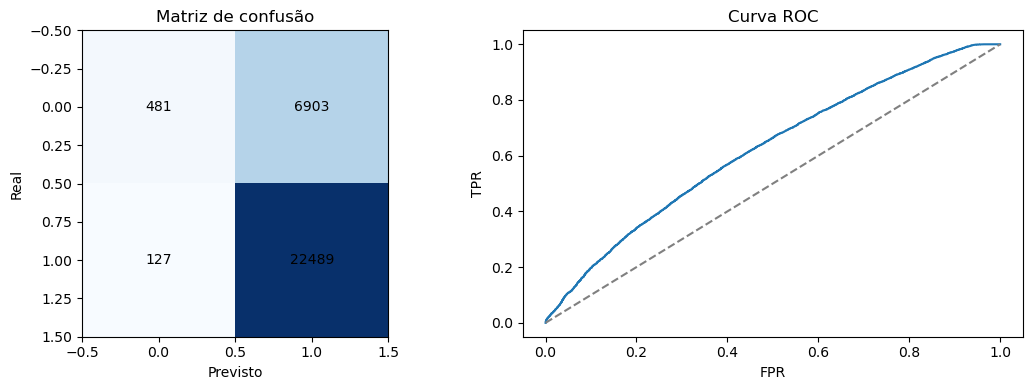

/opt/conda/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:21:32] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


In [8]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, classification_report,
    confusion_matrix, roc_curve)

label = "high_tip"
X_train, y_train = train.drop(columns=[label]), train[label]
X_val,   y_val   = val.drop(columns=[label]),   val[label]
X_test,  y_test  = test.drop(columns=[label]),  test[label]

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)


params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "max_depth": 6,
    "eta": 0.2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}
booster = xgb.train(
    params, dtrain, num_boost_round=200,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=20, verbose_eval=20,
)

# avaliação no teste
y_score = booster.predict(dtest)
y_pred  = (y_score >= 0.5).astype(int)
print("AUC:", round(roc_auc_score(y_test, y_score), 4))
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cm = confusion_matrix(y_test, y_pred)
ax[0].imshow(cm, cmap="Blues"); ax[0].set_title("Matriz de confusão")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, str(v), ha="center", va="center")
ax[0].set_xlabel("Previsto"); ax[0].set_ylabel("Real")

fpr, tpr, _ = roc_curve(y_test, y_score)
ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_title("Curva ROC"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
plt.tight_layout(); plt.savefig("./eval.png", dpi=120); plt.show()

booster.save_model("xgboost-model")


In [13]:
# Salvando o modelo no S3

import os, tarfile, pickle
import sagemaker
from sagemaker.model import Model
from sagemaker.serverless import ServerlessInferenceConfig
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer

with open("xgboost-model", "wb") as f:
    pickle.dump(booster, f)

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("xgboost-model", arcname="xgboost-model")
BUCKET_ = BUCKET.replace("s3://", "").replace("/", "")
model_data = session.upload_data("model.tar.gz", bucket=BUCKET_, key_prefix="xgboost/model")
print("Modelo em:", model_data)

Modelo em: s3://ny-taxi-pedro/xgboost/model/model.tar.gz


In [25]:
# Deploy serverless
from sagemaker.predictor import Predictor

image_uri = sagemaker.image_uris.retrieve("xgboost", region, version="1.7-1")
model = Model(image_uri=image_uri, model_data=model_data, role=role, sagemaker_session=session, predictor_cls=Predictor)
predictor = model.deploy(
    serverless_inference_config=ServerlessInferenceConfig(
        memory_size_in_mb=2048,
        max_concurrency=3,
    ),
    endpoint_name="nyc-taxi-tip-endpoint"
)
predictor.serializer = CSVSerializer()
predictor.deserializer = CSVDeserializer()
print("Endpoint no ar:", predictor.endpoint_name)

-----!Endpoint no ar: nyc-taxi-tip-endpoint


In [26]:
# Teste do deploy com dados de teste

sample_row = X_test.iloc[0].tolist()
payload = ",".join(str(v) for v in sample_row)
prob = float(predictor.predict(payload)[0][0])
print(f"Probabilidade de gorjeta alta: {prob:.3f}  →  {'ALTA' if prob >= 0.5 else 'baixa'}")
print(f"Valor real: {y_test.iloc[0]}")

Probabilidade de gorjeta alta: 0.781  →  ALTA
Valor real: 1


In [ ]:
# Deleta o endpoint e o FeatureGroup para evitar custos

from sagemaker.feature_store.feature_group import FeatureGroup
FeatureGroup(name=FEATURE_GROUP, sagemaker_session=session).delete()
print("Feature group deletada.")

predictor.delete_endpoint()
print("Endpoint deletado.")

Feature group deletada.
Endpoint deletado.
